Número de características: 30
Generación 1 - Mejor accuracy: 0.9719
Generación 2 - Mejor accuracy: 0.9666
Generación 3 - Mejor accuracy: 0.9684
Generación 4 - Mejor accuracy: 0.9684
Generación 5 - Mejor accuracy: 0.9684
Generación 6 - Mejor accuracy: 0.9701
Generación 7 - Mejor accuracy: 0.9684
Generación 8 - Mejor accuracy: 0.9719
Generación 9 - Mejor accuracy: 0.9684
Generación 10 - Mejor accuracy: 0.9702
Generación 11 - Mejor accuracy: 0.9702
Generación 12 - Mejor accuracy: 0.9719
Generación 13 - Mejor accuracy: 0.9702
Generación 14 - Mejor accuracy: 0.9737
Generación 15 - Mejor accuracy: 0.9702

MEJOR SOLUCIÓN ENCONTRADA
Vector de selección:
[0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 1 1 0 0 0 1 1]
Número de variables seleccionadas: 11
Mejor accuracy: 0.9701288619779538


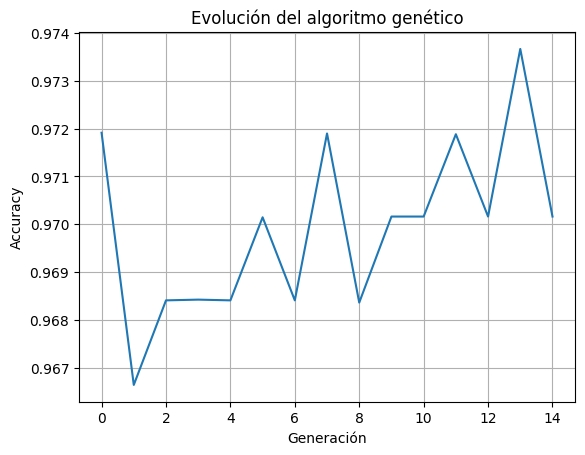


Variables seleccionadas:
- mean texture
- mean concave points
- area error
- smoothness error
- compactness error
- concave points error
- worst texture
- worst area
- worst smoothness
- worst symmetry
- worst fractal dimension

Resumen del entrenamiento:


,Generación,Mejor Accuracy
0,1,0.971914
1,2,0.966636
2,3,0.968406
3,4,0.968421
4,5,0.968406
5,6,0.970144
6,7,0.968406
7,8,0.971899
8,9,0.968359
9,10,0.970160


In [2]:
# ==========================================
# ALGORITMO GENÉTICO PARA FEATURE SELECTION
# ==========================================

import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# 1. CARGA DE DATOS
# ==========================================
data = load_breast_cancer()
X = data.data
y = data.target

n_features = X.shape[1]

print("Número de características:", n_features)

# ==========================================
# 2. CREAR INDIVIDUO (CROMOSOMA)
# ==========================================
def create_individual():
    return np.random.randint(0, 2, n_features)

# ==========================================
# 3. FUNCIÓN FITNESS
# ==========================================
def fitness(individual):
    if np.sum(individual) == 0:
        return 0

    selected = X[:, individual == 1]

    model = RandomForestClassifier(n_estimators=50)

    score = cross_val_score(model, selected, y, cv=5).mean()

    return score

# ==========================================
# 4. SELECCIÓN
# ==========================================
def selection(population):
    population = sorted(population, key=lambda ind: fitness(ind), reverse=True)
    return population[:len(population)//2]

# ==========================================
# 5. CRUZAMIENTO
# ==========================================
def crossover(p1, p2):
    point = random.randint(1, n_features - 1)
    child = np.concatenate([p1[:point], p2[point:]])
    return child

# ==========================================
# 6. MUTACIÓN
# ==========================================
def mutation(individual, rate=0.05):
    for i in range(len(individual)):
        if random.random() < rate:
            individual[i] = 1 - individual[i]
    return individual

# ==========================================
# 7. PARÁMETROS DEL AG
# ==========================================
population_size = 20
generations = 15

# Inicialización
population = [create_individual() for _ in range(population_size)]

best_scores = []

# ==========================================
# 8. CICLO PRINCIPAL
# ==========================================
for gen in range(generations):

    scores = [fitness(ind) for ind in population]
    best_score = max(scores)
    best_scores.append(best_score)

    print(f"Generación {gen+1} - Mejor accuracy: {best_score:.4f}")

    # Selección
    selected = selection(population)

    # Nueva población
    new_population = selected.copy()

    while len(new_population) < population_size:
        p1, p2 = random.sample(selected, 2)
        child = crossover(p1, p2)
        child = mutation(child)
        new_population.append(child)

    population = new_population

# ==========================================
# 9. MEJOR SOLUCIÓN
# ==========================================
best_individual = max(population, key=lambda ind: fitness(ind))

print("\n==============================")
print("MEJOR SOLUCIÓN ENCONTRADA")
print("==============================")

print("Vector de selección:")
print(best_individual)

print("Número de variables seleccionadas:", np.sum(best_individual))
print("Mejor accuracy:", fitness(best_individual))

# ==========================================
# 10. GRÁFICA (BONITO PARA EL PROFESOR)
# ==========================================
plt.plot(best_scores)
plt.title("Evolución del algoritmo genético")
plt.xlabel("Generación")
plt.ylabel("Accuracy")
plt.grid()
plt.show()
# ==========================================
# MOSTRAR VARIABLES SELECCIONADAS (BONITO)
# ==========================================
feature_names = data.feature_names

selected_features = [feature_names[i] for i in range(len(best_individual)) if best_individual[i] == 1]

print("\nVariables seleccionadas:")
for f in selected_features:
    print("-", f)

# ==========================================
# TABLA RESUMEN
# ==========================================
df_result = pd.DataFrame({
    "Generación": list(range(1, generations + 1)),
    "Mejor Accuracy": best_scores
})

print("\nResumen del entrenamiento:")
display(df_result)